# Resistencia a la compresión del concreto de alto rendimiento

**Integrantes:**

- Andrés Camilo Henao Serna.
- Anderson Fabian Blanco.
- Isabel Cristina Suárez Roldán.

La predicción precisa de la resistencia a la compresión del concreto es una tarea crítica en el campo de la ingeniería civil, ya que determina la durabilidad y seguridad de las estructuras construidas. Tradicionalmente, estas predicciones se basaban en métodos experimentales costosos y extensos. Sin embargo, con el avance del aprendizaje automático, se han desarrollado técnicas más eficientes y precisas para modelar estas propiedades a partir de la composición de materiales.

Esta conjunto de datos proporciona información detallada sobre la composición de mezclas de concreto de alto rendimiento. Cada registro contiene mediciones de cantidades de materiales clave (como cemento, agua, agregados, etc.) junto con la edad del concreto en días, y la variable objetivo es la resistencia a la compresión (MPa).

**Objetivo del proyecto:**

Aplicar técnicas de regresión supervisada para predecir la resistencia a la compresión del concreto a partir de sus características de composición. Esto permitirá entender mejor qué factores influyen más en la resistencia y cómo optimizar las mezclas para obtener mejores resultados.

## Preparación del Dataset

**1. Librerias y configuraciones previas**

In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math

# Preparación de datos
# ==============================================================================
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

**2. Funciones**

In [2]:
# Funciones externas
# ==============================================================================
from utils.funciones import multiple_plot

**3. Cargar Dataset**

Este dataset extraido de Kaggle (nombrado: Concrete_Data_Yeh.csv ) contiene información sobre las proporciones de materiales y la edad del concreto.

**A continuación una breve descripción de las variables:**

| Campo                          | Descripción                     | Ejemplo                 |
| :---------------------------- | :------------------------------ | :----------------------- |
| Cement (component 1)          | kg in a m3 mixture              | Input variable           |
| Blast Furnace Slag (component 2) | kg in a m3 mixture           | Input variable           |
| Fly Ash (component 3)         | kg in a m3 mixture              | Input variable           |
| Water (component 4)           | kg in a m3 mixture              | Input variable           |
| Superplasticizer (component 5)| kg in a m3 mixture              | Input variable           |
| Coarse Aggregate (component 6)| kg in a m3 mixture              | Input variable           |
| Fine Aggregate (component 7)  | kg in a m3 mixture              | Input variable           |
| Age                           | Day (1~365)                     | Input variable           |
| Concrete compressive strength | MPa                             | Output variable          |

Url origen datos: https://www.kaggle.com/datasets/maajdl/yeh-concret-data/data

**4. Exploración inicial de datos**

In [3]:
# Cargar el dataset (formato CSV)
df = pd.read_csv('Concrete_Data_Yeh.csv', engine='python', encoding='utf-8')

In [4]:
# Mostrar las primeras filas para entender la estructura
print("Primeras 5 filas del dataset:")
df.head()

Primeras 5 filas del dataset:


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
# Dimensiones del dataset
print("\nDimensiones del dataset (filas, columnas):")
print(df.shape)


Dimensiones del dataset (filas, columnas):
(1030, 9)


In [6]:
# Ver nombres de las columnas
print("\nColumnas del dataset:", df.columns.tolist())


Columnas del dataset: ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age', 'csMPa']


In [7]:
# Información sobre tipos de datos y valores no nulos
print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB
None


In [8]:
# Estadísticas descriptivas
print("\nESTADÍSTICAS DESCRIPTIVAS DE COLUMNAS NUMÉRICAS:")
print(df.describe())


ESTADÍSTICAS DESCRIPTIVAS DE COLUMNAS NUMÉRICAS:
            cement         slag       flyash        water  superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.000000   121.800000          0.000000   
25%     192.375000     0.000000     0.000000   164.900000          0.000000   
50%     272.900000    22.000000     0.000000   185.000000          6.400000   
75%     350.000000   142.950000   118.300000   192.000000         10.200000   
max     540.000000   359.400000   200.100000   247.000000         32.200000   

       coarseaggregate  fineaggregate          age        csMPa  
count      1030.000000    1030.000000  1030.000000  1030.000000  
mean        972.918932     773.580485    45.662136    35.817961  
std          77.753954      80.175980   

In [9]:
# Verificar valores faltantes
print("\nValores faltantes por columna:")
missing_values = df.isnull().sum()
print(missing_values)
print("\nPorcentaje de valores faltantes:")
print((missing_values / len(df) * 100).round(2))


Valores faltantes por columna:
cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

Porcentaje de valores faltantes:
cement              0.0
slag                0.0
flyash              0.0
water               0.0
superplasticizer    0.0
coarseaggregate     0.0
fineaggregate       0.0
age                 0.0
csMPa               0.0
dtype: float64


**5. Limpieza de datos:**

In [10]:
# Chequeo de duplicados
df.loc[df.duplicated()]

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
100,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7,49.20
103,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7,49.20
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
111,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
123,425.0,106.3,0.0,153.5,16.5,852.1,887.1,28,60.29


In [11]:
# eliminación de registros duplicados
df = df.drop_duplicates()

#Reiniciar el indice
df.reset_index(drop=True, inplace=True) 

**6. Visualización de datos:**

**Variables de entrada y salida:**

In [12]:
# Variable objetivo
target = 'csMPa'

# Variables de entrada (todas las demás)
inputVars = [col for col in df.columns if col != target]
# Variable de salida
outputVar = target

print("Variables de entrada:", inputVars)
print("Variable de salida:", outputVar)

Variables de entrada: ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age']
Variable de salida: csMPa


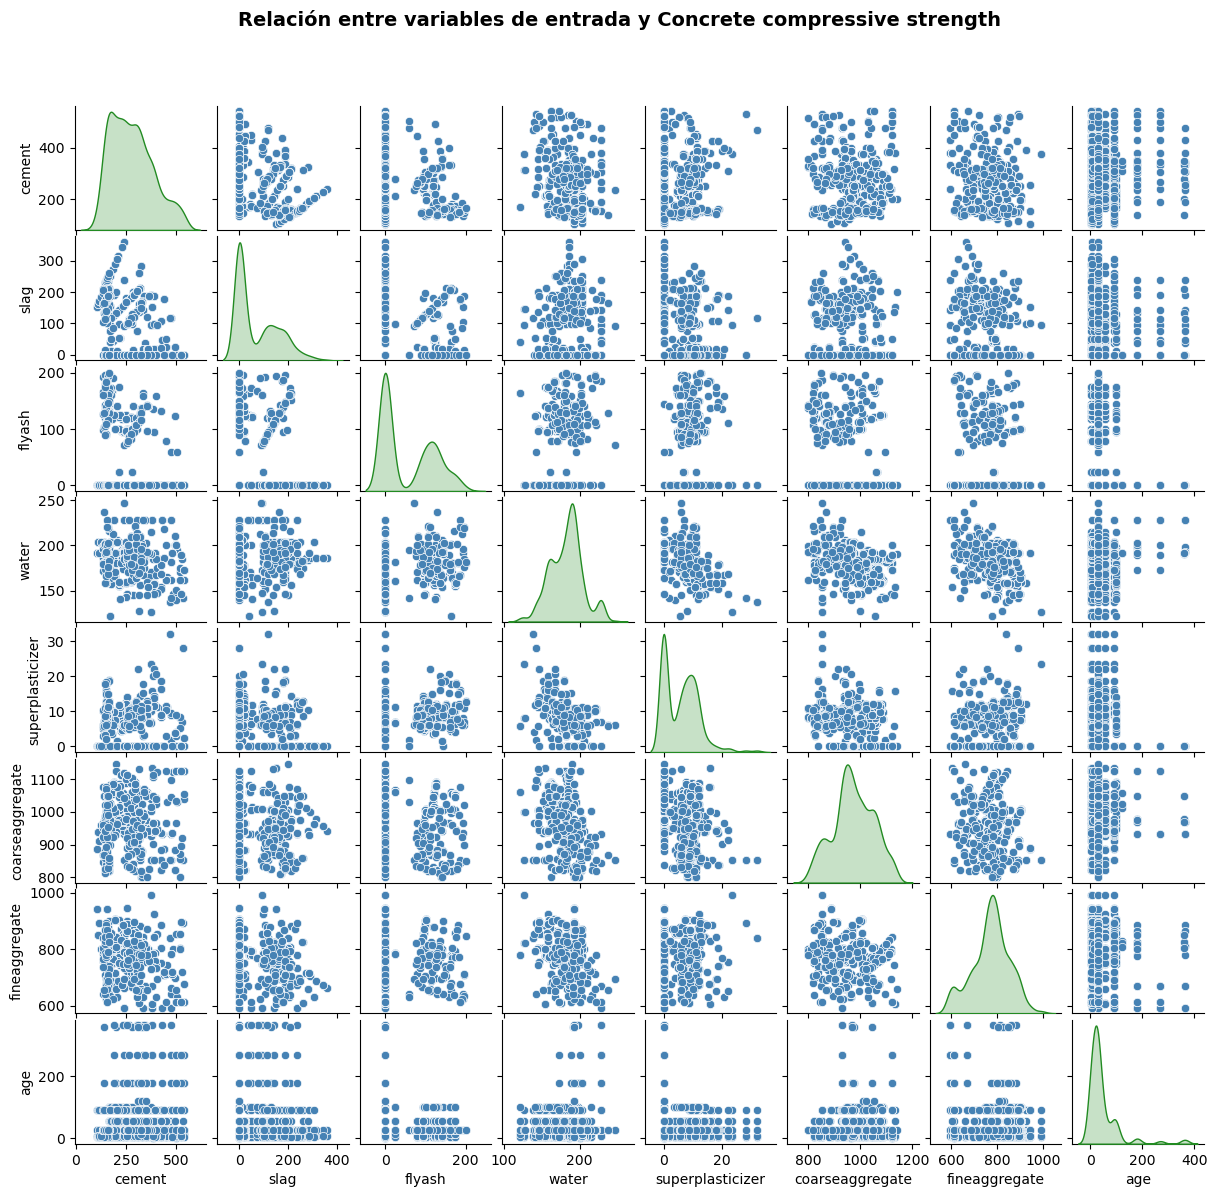

In [13]:
# Visualización de variables numéricas respecto a csMPa (Concrete compressive strength)
multiple_plot(1, df, inputVars, outputVar, 'scatterplot', 'Relación entre variables de entrada y Concrete compressive strength', 30)

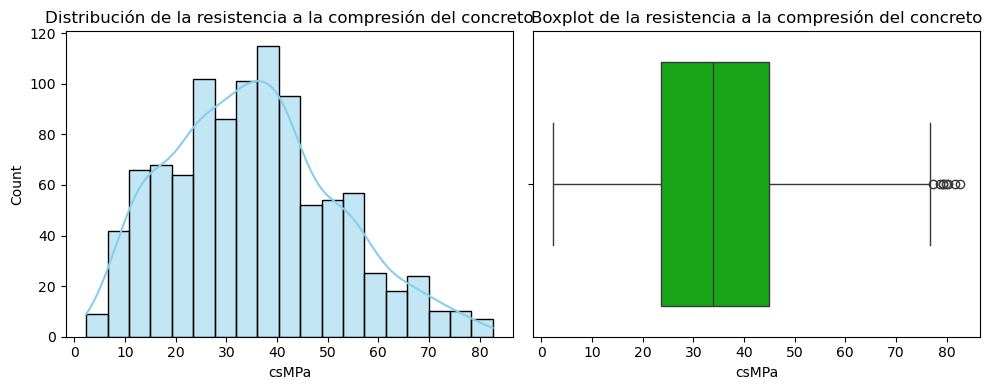

In [14]:
# Visualizar la distribución de la variable de salida

plt.figure(figsize=(12, 4))

# Histograma
plt.subplot(1, 2, 1)
plt.title('Distribución de la resistencia a la compresión del concreto')
sns.histplot(df[outputVar], kde=True, color='skyblue')

# Boxplot
plt.subplot(1, 2, 2)
plt.title('Boxplot de la resistencia a la compresión del concreto')
sns.boxplot(x=df[outputVar], palette='nipy_spectral')

plt.tight_layout()
plt.show()


In [15]:
#Descripción de la variable de salida

#Configuración de formato de visualización
pd.set_option('display.float_format', lambda x: '%.0f' % x)

#Descripción
print(df['csMPa'].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.975,1]))

count   1005
mean      35
std       16
min        2
25%       24
50%       34
75%       45
85%       53
90%       57
95%       66
97.5%     71
100%      83
max       83
Name: csMPa, dtype: float64


**7. Preparación de datos**

**Valores atípicos de la variable de salida**

In [16]:
#Calculo de valores atípicos

#Calculo de Q1 t Q3
Q1 = np.percentile(df['csMPa'], 25, interpolation = 'midpoint') 
Q3 = np.percentile(df['csMPa'], 75, interpolation = 'midpoint') 
  
#Cálculo del rango intercuartil    
IQR = Q3 - Q1 

#Cálculo de valor mínimo y máximo para los valores atípicos
VAInf = Q1 - 1.5*IQR
VASup = Q3 + 1.5*IQR
   
print(f'Valor atípico leve inferior:{VAInf}') 
print(f'Valor atípico leve superior:{VASup}') 


Valor atípico leve inferior:-8.504999999999999
Valor atípico leve superior:76.895


In [17]:
# Se eliminan los valores atípicos
df = df.drop(df[df['csMPa']>VASup].index)

#Reiniciar el indice
df.reset_index(drop=True, inplace=True) 

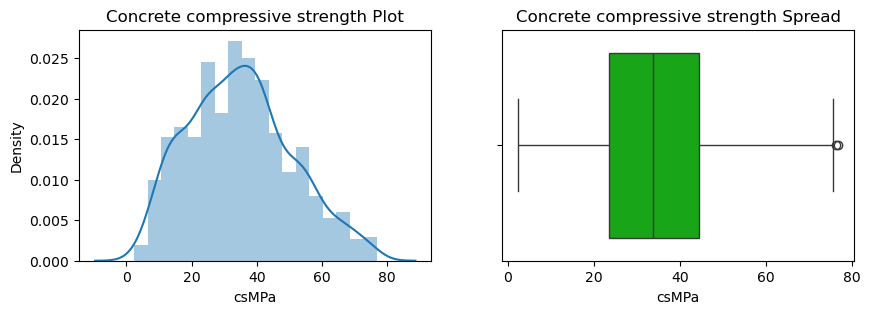

In [18]:
#Histográma y caja de bigotes de Concrete compressive strength

plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.title('Concrete compressive strength Plot')
sns.distplot(df['csMPa'])

plt.subplot(1,2,2)
plt.title('Concrete compressive strength Spread')
sns.boxplot(x=df['csMPa'], palette='nipy_spectral')

plt.show()

In [19]:
#Descripción del Concrete compressive strength después de eliminar valores atípicos

print(df['csMPa'].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.975,1]))

count   997
mean     35
std      16
min       2
25%      24
50%      34
75%      45
85%      53
90%      56
95%      64
97.5%    68
100%     77
max      77
Name: csMPa, dtype: float64


**8. Imputaciones:**

In [20]:
#Identificación de valores nulos para las variables de entrada
for col in df[inputVars]:
    print (col, np.sum(pd.isnull(df[col])))

cement 0
slag 0
flyash 0
water 0
superplasticizer 0
coarseaggregate 0
fineaggregate 0
age 0


**Nota:** Como no tengo valores nulos no es necesario hacer imputaciones.

**9. Valores atípicos para las variables de entrada**

In [21]:
#utilización de LocalOutlierFactor con 13 vecinos para identificar valores atípicos en las variables de entrada

# crear un objeto LocalOutlierFactor con n_neighbors=13
lof = LocalOutlierFactor(n_neighbors=13, contamination=0.1)

# identificar los valores atípicos por medio de lof 
y_pred = lof.fit_predict(df[inputVars])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print('Indices de valores atípicos: ', df[outliers].index.tolist())

Indices de valores atípicos:  [0, 22, 31, 50, 65, 67, 68, 78, 82, 83, 84, 96, 100, 101, 102, 115, 119, 120, 121, 133, 135, 137, 139, 140, 148, 150, 151, 152, 153, 265, 304, 306, 309, 310, 311, 312, 313, 349, 350, 351, 354, 358, 359, 360, 361, 362, 363, 369, 371, 373, 426, 483, 484, 485, 486, 499, 505, 506, 507, 508, 510, 537, 554, 578, 584, 588, 595, 596, 708, 709, 710, 722, 723, 724, 737, 742, 751, 752, 760, 763, 764, 765, 766, 773, 781, 786, 787, 793, 813, 841, 857, 858, 870, 885, 898, 904, 920, 921, 933, 948]


In [22]:
# Eliminar los valores atípicos del dataframe original
df = df.loc[~outliers]

**10.Transformaciones**

**Crear categorías a partir de Age**

In [23]:
# Crear una columna categórica a partir de 'Age'
def categorizar_edad(age):
    if age <= 28:
        return 'Joven'
    elif age <= 180:
        return 'Mediana'
    else:
        return 'Vieja'

df['Age_Categoria'] = df['age'].apply(categorizar_edad)

# Ver cuántas instancias hay por categoría
print(df['Age_Categoria'].value_counts())

Age_Categoria
Joven      669
Mediana    205
Vieja       23
Name: count, dtype: int64


**Agrupar categorías poco representadas (si las hay)**

In [24]:
# Detectar categorías poco frecuentes
conteo = df['Age_Categoria'].value_counts()
categorias_a_reemplazar = conteo[conteo < 20].index.tolist()

# Reemplazar categorías poco frecuentes por 'Otro'
df['Age_Categoria'] = df['Age_Categoria'].replace(categorias_a_reemplazar, 'Otro')

**Codificación de variables categóricas (como Age_Categoria)**

In [25]:
# Confirmar que existe
print(df['Age_Categoria'].value_counts())

# Hacer One-hot Encoding
df = pd.get_dummies(df, columns=['Age_Categoria'], drop_first=True)

# Verificar
print(df.filter(like='Age_Categoria').head())
print(df.filter(like='Age_Categoria').sum())

Age_Categoria
Joven      669
Mediana    205
Vieja       23
Name: count, dtype: int64
   Age_Categoria_Mediana  Age_Categoria_Vieja
1                  False                 True
2                  False                 True
3                  False                 True
4                   True                False
5                  False                 True
Age_Categoria_Mediana    205
Age_Categoria_Vieja       23
dtype: int64


**11. Datos de prueba**

In [26]:
# Porcentaje de filas para la primera parte (por ejemplo, 90%)
percentage_first_part = 0.90

# Número de filas para la primera parte
n_rows_part1 = int(len(df) * percentage_first_part)

# Obtener índices aleatorios para la primer parte
indices_part1 = df.sample(n=n_rows_part1, random_state=123).index

# Obtener índices para la segunda parte (resto de las filas)
indices_part2 = df.index.difference(indices_part1)

# Dividir el DataFrame en dos partes
df2 = df.loc[indices_part1]
dp = df.loc[indices_part2]

In [27]:
dp.shape

(90, 11)

**12. Exportar el dataset**

In [28]:
# Exportamos el dataframe a un archivo CSV
df2.to_csv('Concrete_Data_Yeh_prep.csv', index=False)
dp.to_csv('Concrete_Data_Yeh_prue.csv', index=False)

In [29]:
df2.head(10)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,Age_Categoria_Mediana,Age_Categoria_Vieja
44,428,48,0,228,0,932,594,7,35,False,False
282,296,0,96,172,9,955,859,56,49,True,False
844,296,0,107,221,11,819,778,28,31,False,False
622,123,184,0,204,0,958,800,28,24,False,False
862,260,101,78,171,10,936,763,28,50,False,False
705,238,0,0,186,0,1119,789,28,18,False,False
239,232,0,122,174,7,1056,778,3,15,False,False
393,167,75,167,164,8,1007,770,14,33,False,False
355,520,0,0,175,5,870,805,28,51,False,False
943,298,0,108,164,13,953,784,28,36,False,False
